In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
import pandas as pd
df = pd.read_csv('/content/SEntFiN-v1.1.csv')
df['word_count'] = df['Title'].apply(lambda x: len(x.split()))
display(df.head())

,S No.,Title,Decisions,Words,word_count
0,1,SpiceJet to issue 6.4 crore warrants to promoters,"{""SpiceJet"": ""neutral""}",8,8
1,2,MMTC Q2 net loss at Rs 10.4 crore,"{""MMTC"": ""neutral""}",8,8
2,3,"Mid-cap funds can deliver more, stay put: Experts","{""Mid-cap funds"": ""positive""}",8,8
3,4,Mid caps now turn into market darlings,"{""Mid caps"": ""positive""}",7,7
4,5,"Market seeing patience, if not conviction: Pra...","{""Market"": ""neutral""}",8,8


In [ ]:
df=pd.read_csv('/content/SEntFiN-v1.1.csv')

In [ ]:
df.head()

,S No.,Title,Decisions,Words
0,1,SpiceJet to issue 6.4 crore warrants to promoters,"{""SpiceJet"": ""neutral""}",8
1,2,MMTC Q2 net loss at Rs 10.4 crore,"{""MMTC"": ""neutral""}",8
2,3,"Mid-cap funds can deliver more, stay put: Experts","{""Mid-cap funds"": ""positive""}",8
3,4,Mid caps now turn into market darlings,"{""Mid caps"": ""positive""}",7
4,5,"Market seeing patience, if not conviction: Pra...","{""Market"": ""neutral""}",8


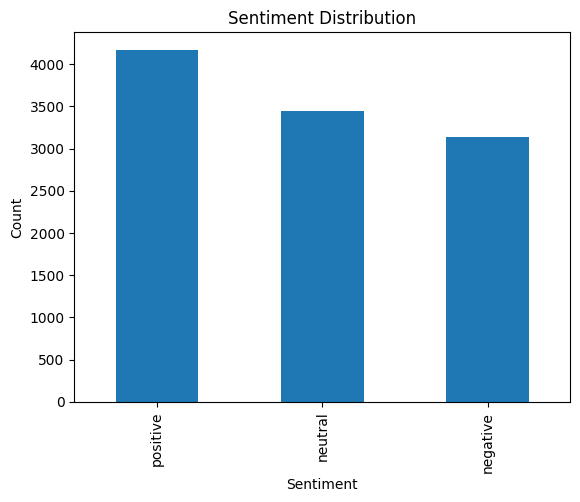

In [ ]:
df['Sentiment'] = df['Decisions'].apply(lambda x: list(eval(x).values())[0])
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

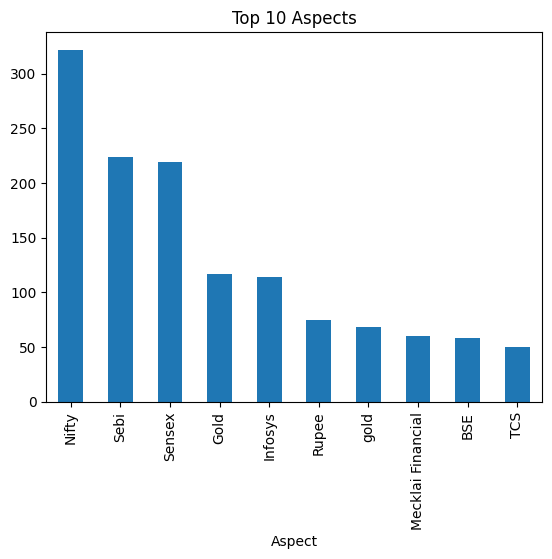

In [ ]:
df['Aspect'] = df['Decisions'].apply(lambda x: list(eval(x).keys())[0])
df['Aspect'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Aspects")
plt.show()

In [ ]:
# Feature Extraction (TF-IDF)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df['Title'])
y = df['Sentiment']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Model 1: Naive Bayes
mnb_model = MultinomialNB()
mnb_model.fit(X_train, y_train)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Model 3: SVM
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
# Evaluate Naive Bayes Model
y_pred_mnb = mnb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_mnb))
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_mnb))
print("Naive Bayes Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mnb))

# Evaluate Logistic Regression Model
y_pred_lr = lr_model.predict(X_test)
print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# Evaluate SVM Model
y_pred_svm = svm_model.predict(X_test)
print("\nSVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Naive Bayes Accuracy: 0.7559274755927475
Naive Bayes Classification Report:
               precision    recall  f1-score   support

    negative       0.83      0.66      0.74       654
     neutral       0.75      0.70      0.73       660
    positive       0.72      0.87      0.79       837

    accuracy                           0.76      2151
   macro avg       0.77      0.75      0.75      2151
weighted avg       0.76      0.76      0.75      2151

Naive Bayes Confusion Matrix:
 [[430  99 125]
 [ 37 465 158]
 [ 49  57 731]]

Logistic Regression Accuracy: 0.8131101813110181
Logistic Regression Classification Report:
               precision    recall  f1-score   support

    negative       0.86      0.75      0.80       654
     neutral       0.75      0.80      0.77       660
    positive       0.83      0.87      0.85       837

    accuracy                           0.81      2151
   macro avg       0.81      0.81      0.81      2151
weighted avg       0.82      0.81      0.81  

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Get classification reports
report_mnb = classification_report(y_test, y_pred_mnb, output_dict=True)
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_svm = classification_report(y_test, y_pred_svm, output_dict=True)

# Extract macro average metrics for comparison
metrics = {
    'Naive Bayes': {
        'Accuracy': accuracy_score(y_test, y_pred_mnb),
        'Precision': report_mnb['macro avg']['precision'],
        'Recall': report_mnb['macro avg']['recall'],
        'F1-Score': report_mnb['macro avg']['f1-score']
    },
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'Precision': report_lr['macro avg']['precision'],
        'Recall': report_lr['macro avg']['recall'],
        'F1-Score': report_lr['macro avg']['f1-score']
    },
    'SVM': {
        'Accuracy': accuracy_score(y_test, y_pred_svm),
        'Precision': report_svm['macro avg']['precision'],
        'Recall': report_svm['macro avg']['recall'],
        'F1-Score': report_svm['macro avg']['f1-score']
    }
}

comparison_df = pd.DataFrame(metrics).T
display(comparison_df.round(4))


,Accuracy,Precision,Recall,F1-Score
Naive Bayes,0.7559,0.7677,0.7451,0.7503
Logistic Regression,0.8131,0.8144,0.8077,0.8095
SVM,0.8140,0.8177,0.8077,0.8097


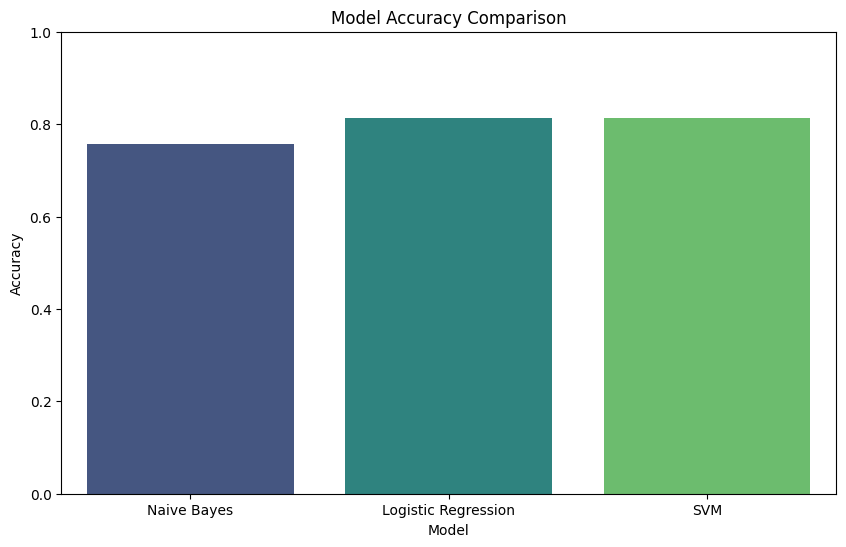

In [ ]:
model_names = ['Naive Bayes', 'Logistic Regression', 'SVM']
accuracy_scores = [accuracy_score(y_test, y_pred_mnb), accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_svm)]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracy_scores, hue=model_names, palette='viridis', legend=False)
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

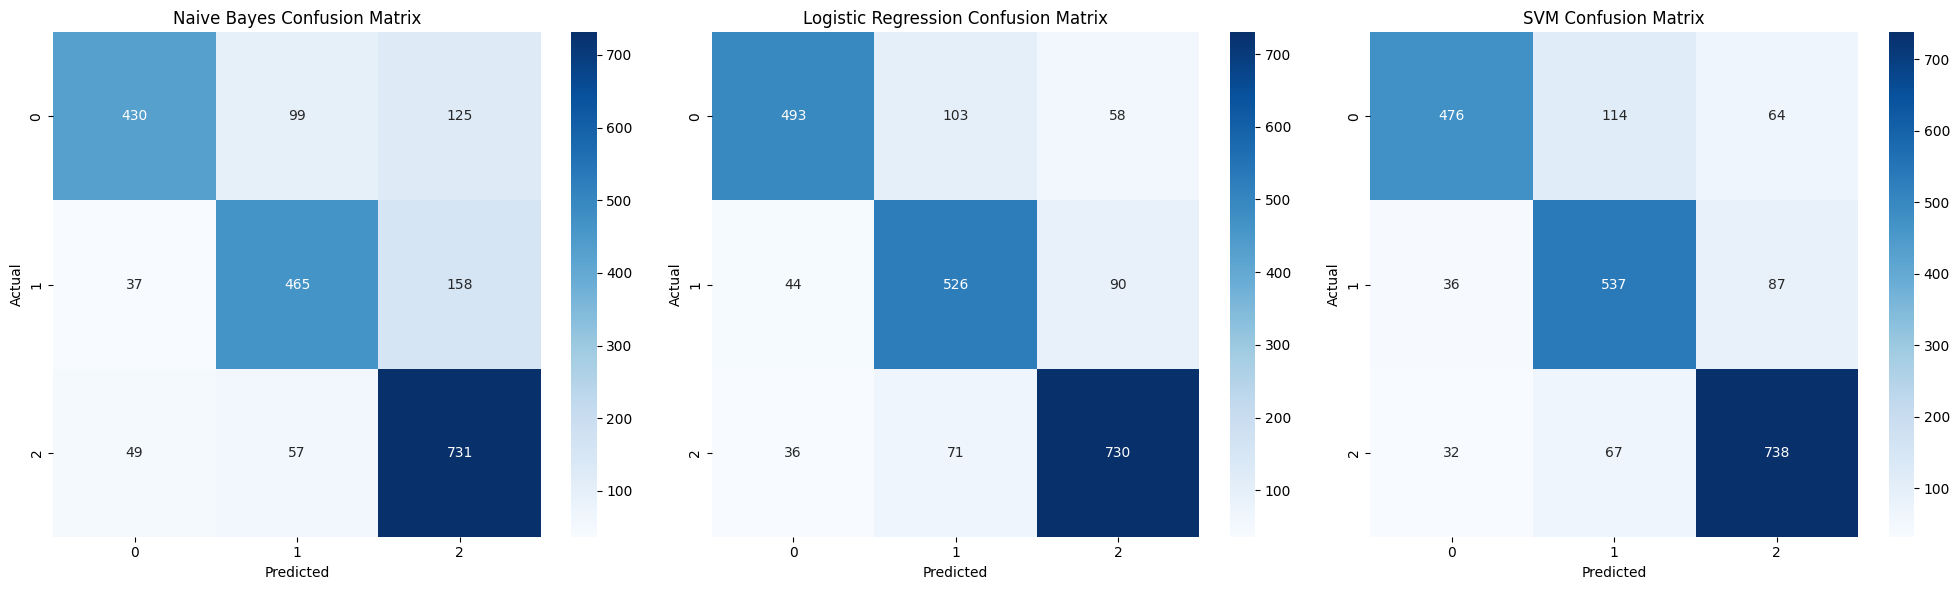

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(confusion_matrix(y_test, y_pred_mnb), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Naive Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('SVM Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
sample_texts = [
    "Good results for the company and investors",
    "Market is down due to bad news",
    "Company announced neutral earnings guidance",
    "The company reported strong growth, but concerns about future market conditions remain."
]

# Vectorize the sample texts using the fitted TF-IDF vectorizer
X_sample = tfidf_vectorizer.transform(sample_texts)

print("\n--- Sample Predictions ---")

# Predict with Naive Bayes
pred_mnb_sample = mnb_model.predict(X_sample)
print("Naive Bayes Predictions:")
for text, pred in zip(sample_texts, pred_mnb_sample):
    print(f"  Text: '{text}' -> Sentiment: {pred}")

# Predict with Logistic Regression
pred_lr_sample = lr_model.predict(X_sample)
print("\nLogistic Regression Predictions:")
for text, pred in zip(sample_texts, pred_lr_sample):
    print(f"  Text: '{text}' -> Sentiment: {pred}")

# Predict with SVM
pred_svm_sample = svm_model.predict(X_sample)
print("\nSVM Predictions:")
for text, pred in zip(sample_texts, pred_svm_sample):
    print(f"  Text: '{text}' -> Sentiment: {pred}")


--- Sample Predictions ---
Naive Bayes Predictions:
  Text: 'Good results for the company and investors' -> Sentiment: positive
  Text: 'Market is down due to bad news' -> Sentiment: negative
  Text: 'Company announced neutral earnings guidance' -> Sentiment: neutral
  Text: 'The company reported strong growth, but concerns about future market conditions remain.' -> Sentiment: neutral

Logistic Regression Predictions:
  Text: 'Good results for the company and investors' -> Sentiment: positive
  Text: 'Market is down due to bad news' -> Sentiment: negative
  Text: 'Company announced neutral earnings guidance' -> Sentiment: neutral
  Text: 'The company reported strong growth, but concerns about future market conditions remain.' -> Sentiment: neutral

SVM Predictions:
  Text: 'Good results for the company and investors' -> Sentiment: positive
  Text: 'Market is down due to bad news' -> Sentiment: negative
  Text: 'Company announced neutral earnings guidance' -> Sentiment: neutral
  Text:

In [ ]:
sample_texts = [
    "jbfsjdvsbbfsd",

]

# Vectorize the sample texts using the fitted TF-IDF vectorizer
X_sample = tfidf_vectorizer.transform(sample_texts)

print("\n--- Sample Predictions ---")

# Predict with Naive Bayes
pred_mnb_sample = mnb_model.predict(X_sample)
print("Naive Bayes Predictions:")
for text, pred in zip(sample_texts, pred_mnb_sample):
    print(f"  Text: '{text}' -> Sentiment: {pred}")

# Predict with Logistic Regression
pred_lr_sample = lr_model.predict(X_sample)
print("\nLogistic Regression Predictions:")
for text, pred in zip(sample_texts, pred_lr_sample):
    print(f"  Text: '{text}' -> Sentiment: {pred}")

# Predict with SVM
pred_svm_sample = svm_model.predict(X_sample)
print("\nSVM Predictions:")
for text, pred in zip(sample_texts, pred_svm_sample):
    print(f"  Text: '{text}' -> Sentiment: {pred}")


--- Sample Predictions ---
Naive Bayes Predictions:
  Text: 'jbfsjdvsbbfsd' -> Sentiment: positive

Logistic Regression Predictions:
  Text: 'jbfsjdvsbbfsd' -> Sentiment: neutral

SVM Predictions:
  Text: 'jbfsjdvsbbfsd' -> Sentiment: neutral
